### Pristine Lu intensities

In [1]:
from pathlib import Path
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from tqdm import tqdm

sys.path.append("..")
import roi_tools

rng = np.random.default_rng(0)
n_fp = 50
n_pristine_images = 30

metric = "mean_intensity"

configs = {
    "4 Atoms": [(0, -2), (0, 2), (-1, 0), (1, 0)],
    "8 Atoms": [
        (0, -2), (0, 2),
        (-1, -2), (-1, 0), (-1, 2),
        (1, -2), (1, 0), (1, 2),
    ],
    "14 Atoms": [
        (0, -2), (0, 2),
        (-1, -2), (-1, 0), (-1, 2),
        (1, -2), (1, 0), (1, 2),
        (-2, -2), (-2, 0), (-2, 2),
        (2, -2), (2, 0), (2, 2),
    ],
    # "10 Atoms": [
    #     (0, -2), (0, 2),
    #     (-1, -2), (-1, 0), (-1, 2),
    #     (1, -2), (1, 0), (1, 2),
    #     (-2, 0), (2, 0),
    # ],
}


def indexed_files(folder, pattern):
    return sorted(
        folder.glob(pattern),
        key=lambda path: int(path.stem.rsplit("_", 1)[1]),
    )
def mean_selected(files, indices):
    return np.mean(
        np.stack([np.load(files[index]).squeeze() for index in indices]),
        axis=0,
    )

pristine_dir = Path("../data/simulations/pristine_fp")
pristine_files = indexed_files(pristine_dir, "pristine_fp_*.npy")

def random_index_sets(n_available, n_images):
    return np.array([
        np.sort(rng.choice(n_available, n_fp, replace=False))
        for _ in range(n_images)
    ])

pristine_index_sets = random_index_sets(len(pristine_files), n_pristine_images)
pristine_images = [
    mean_selected(pristine_files, indices)
    for indices in tqdm(pristine_index_sets, desc="Building pristine ensembles")
]

print(f"Pristine ensemble images: {len(pristine_images)}")

Building pristine ensembles: 100%|██████████| 30/30 [00:00<00:00, 42.68it/s]

Pristine ensemble images: 30


In [2]:
grid_creator = roi_tools.GridCreator()
intensity_analyzer = roi_tools.IntensityAnalyzer()

pristine_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(pristine_images[0])
)
def analyze(signal, layout):
    grid = grid_creator.process(signal, layout=layout)
    intensities = intensity_analyzer.values(grid, metric=metric)
    relative = {
        name: intensity_analyzer.relative_vicinity(
            grid, offsets=offsets, metric=metric, values=intensities
        )
        for name, offsets in configs.items()
    }
    return grid, relative


pristine_samples = {name: [] for name in configs}
for image in tqdm(pristine_images, desc="Analyzing pristine ensembles"):
    grid, relative = analyze(hs.signals.Signal2D(image), pristine_layout)
    interior_x_mask = np.zeros(grid.shape, dtype=bool)
    interior_x_mask[2:-2, :] = True
    lu_mask = grid.atom_type_mask("Lu") & interior_x_mask
    for name, values in relative.items():
        pristine_samples[name].append(values[lu_mask & np.isfinite(values)])
pristine_intensities = {
    name: np.concatenate(values) for name, values in pristine_samples.items()
}

Analyzing pristine ensembles: 100%|██████████| 30/30 [00:04<00:00,  7.30it/s]


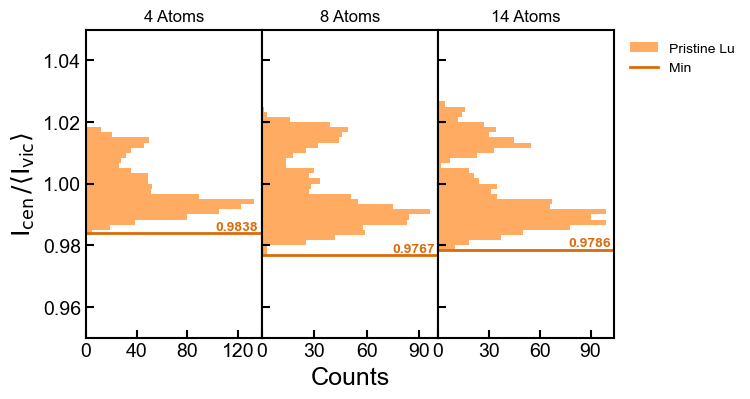

In [16]:
hist_min = 0.95
hist_max = 1.05
n_bins = 60
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": False,
})

fig, axes = plt.subplots(1, len(configs), figsize=(7, 4), sharey=True)

for ax, (name, values) in zip(axes, pristine_intensities.items()):
    mean, std, maximum, minimum = values.mean(), values.std(), values.max(), values.min()
    ax.hist(values, bins=n_bins, range=(hist_min, hist_max), color="#ff7f0e", alpha=0.65, orientation="horizontal", label="Pristine Lu")
    # ax.axhspan(mean - std, mean + std, color="#d62728", alpha=0.2)
    # ax.axhline(mean, color="#d62728", linestyle="--", label="Mean")
    # ax.axhline(maximum, color="#da6c0c", linewidth=2, label="Max")
    ax.axhline(minimum, color="#da6c0c", linewidth=2, label="Min")
    transform = ax.get_yaxis_transform()
    ax.text(0.98, minimum, f"{minimum:.4f}", transform=transform, ha="right", va="bottom", color="#da6c0c", fontweight="bold")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True))
    ax.tick_params(direction="in", length=6)
    ax.set_ylim(hist_min, hist_max)

axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.88)
plt.show()

### Fe_Lu simulations

In [4]:
n_singlet_images = 10
n_doublet_images = 20
singlet_target = (3, 4)
doublet_target = (4, 4)
layers = np.arange(25)

def defect_files(defect):
    defect_dir = Path("../data/simulations") / defect
    return {
        layer: indexed_files(
            defect_dir / f"{defect}_layer_{layer}",
            f"{defect}_layer_{layer}_ensemble_*.npy",
        )
        for layer in layers
    }


def build_defect_images(files_by_layer, index_sets, description):
    return {
        layer: [mean_selected(files, indices) for indices in index_sets]
        for layer, files in tqdm(files_by_layer.items(), desc=description)
    }


singlet_files = defect_files("FeLu_singlet")
doublet_files = defect_files("FeLu_doublet")
singlet_index_sets = random_index_sets(
    len(singlet_files[layers[0]]), n_singlet_images
)
doublet_index_sets = random_index_sets(
    len(doublet_files[layers[0]]), n_doublet_images
)
singlet_images = build_defect_images(
    singlet_files, singlet_index_sets, "Building FeLu_singlet ensembles"
)
doublet_images = build_defect_images(
    doublet_files, doublet_index_sets, "Building FeLu_doublet ensembles"
)

singlet_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(singlet_images[layers[0]][0])
)
doublet_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(doublet_images[layers[0]][0])
)


def analyze_defect_images(images_by_layer, layout, target, description):
    n_images = len(images_by_layer[layers[0]])
    metrics = {
        name: np.full((len(layers), n_images), np.nan) for name in configs
    }
    with tqdm(total=len(layers) * n_images, desc=description) as progress:
        for layer, images in images_by_layer.items():
            for image_index, image in enumerate(images):
                grid, relative = analyze(hs.signals.Signal2D(image), layout)
                if grid.atom_types[target] != "Lu":
                    raise ValueError(
                        f"Target {target} is not classified as Lu in layer {layer}"
                    )
                for name, values in relative.items():
                    metrics[name][layer, image_index] = values[target]
                progress.update()
    return metrics


singlet_metrics = analyze_defect_images(
    singlet_images, singlet_layout, singlet_target,
    "Analyzing FeLu_singlet ensembles",
)
doublet_metrics = analyze_defect_images(
    doublet_images, doublet_layout, doublet_target,
    "Analyzing FeLu_doublet ensembles",
)
felu_metrics = {
    name: np.concatenate((singlet_metrics[name], doublet_metrics[name]), axis=1)
    for name in configs
}

print(f"FeLu_singlet images per layer: {len(singlet_index_sets)}")
print(f"FeLu_doublet images per layer: {len(doublet_index_sets)}")

Analyzing FeLu_doublet ensembles: 100%|██████████| 500/500 [00:25<00:00, 19.80it/s]

FeLu_singlet images per layer: 10
FeLu_doublet images per layer: 20


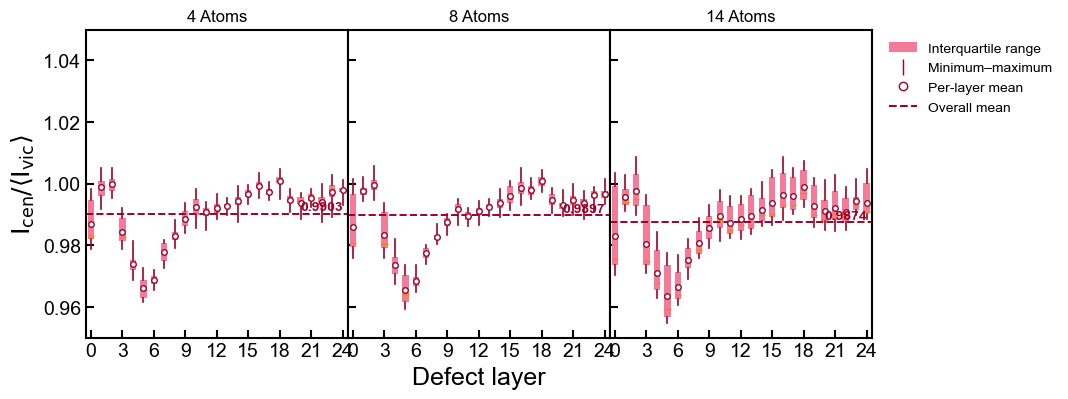

In [15]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

ymin, ymax = 0.95, 1.05
fill, dark = "#F47A98", "#9D0229"

fig, axes = plt.subplots(1, len(felu_metrics), figsize=(12, 4), sharey=True)

for ax, (name, values) in zip(axes, felu_metrics.items()):
    mean = np.nanmean(values)

    ax.boxplot(
        values.T,
        positions=layers,
        widths=0.6,
        whis=(0, 100),
        showcaps=False,
        showfliers=False,
        showmeans=True,
        patch_artist=True,
        manage_ticks=False,
        boxprops={"facecolor": fill, "edgecolor": "none"},
        whiskerprops={"color": dark, "linewidth": 1.2},
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": dark,
            "markersize": 4,
        },
    )

    ax.axhline(mean, color=dark, linestyle="--", linewidth=1.4)
    ax.text(
        0.98,
        mean,
        f"{mean:.4f}",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        color=dark,
        fontweight="bold",
    )

    ax.set_title(name)
    ax.set_xlim(min(layers) - 0.5, max(layers) + 0.5)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(direction="in", length=6)

axes[0].set_ylim(ymin, ymax)
axes[1].set_xlabel("Defect layer")
axes[0].set_ylabel(r"$\mathrm{I_{cen}}/\langle\mathrm{I_{vic}}\rangle$")

handles = [
    Patch(facecolor=fill, edgecolor="none", label="Interquartile range"),
    Line2D([], [], color=dark, marker="|", markersize=12,
           linestyle="none", label="Minimum–maximum"),
    Line2D([], [], color=dark, marker="o", markerfacecolor="white",
           linestyle="none", label="Per-layer mean"),
    Line2D([], [], color=dark, linestyle="--", label="Overall mean"),
]

axes[-1].legend(
    handles=handles,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.subplots_adjust(wspace=0, right=0.78)
plt.show()

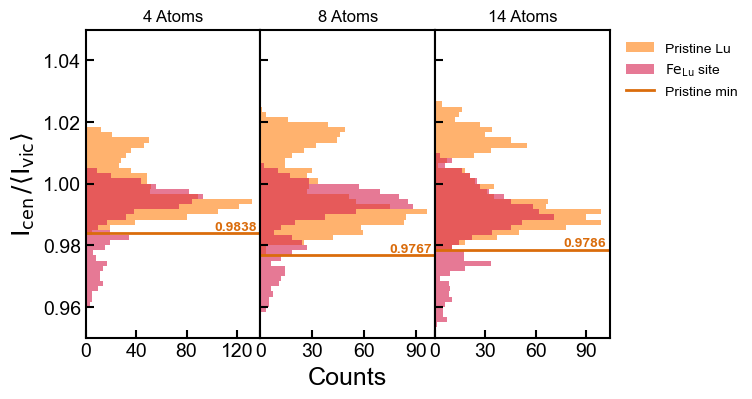

In [13]:
hist_min = 0.95
hist_max = 1.05
n_bins = 60
fig, axes = plt.subplots(1, len(configs), figsize=(8, 4), sharey=True)

for ax, name in zip(axes, configs):
    pristine = pristine_intensities[name]
    defect = felu_metrics[name].ravel()
    defect = defect[np.isfinite(defect)]
    bins = np.linspace(hist_min, hist_max, n_bins + 1)
    ax.hist(pristine, bins=bins, color="#ff7f0e", alpha=0.6, orientation="horizontal", label="Pristine Lu")
    ax.hist(defect, bins=bins, color="#D6204E", alpha=0.6, orientation="horizontal", label=r"$\mathrm{Fe}_{\mathrm{Lu}}$ site")
    ax.axhline(pristine.min(), color="#da6c0c", linestyle="-", label="Pristine min", linewidth=2)
    transform = ax.get_yaxis_transform()
    ax.text(0.98, pristine.min(), f"{pristine.min():.4f}", transform=transform, ha="right", va="bottom", color="#da6c0c", fontweight="bold")
    # ax.axhline(np.nanmean(defect), color="#9D0229", linestyle="--", label="DLu mean")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True))
    ax.tick_params(direction="in", length=6)
    ax.set_ylim(hist_min, hist_max)

axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)), frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.78)
plt.show()

### Experimental defect intensity outliers

In [7]:
from matplotlib.patches import Patch as LegendPatch

experimental_source = hs.load("../data/images/HAADF/HAADF_Buena.dm3")
experimental_signal = experimental_source.isig[20:2028, 200:1948]

# experimental_source = hs.load("../data/images/EELS/EEL SI 22 13/Integrated Shifted Spectrum Image adf.dm3")
# experimental_signal = experimental_source.isig[0:185, 20:235]

experimental_layout = grid_creator.detect_layout(experimental_signal)
experimental_grid = grid_creator.process(
    experimental_signal, layout=experimental_layout
)
experimental_intensities = intensity_analyzer.values(
    experimental_grid, metric=metric
)
experimental_relative = {
    name: intensity_analyzer.relative_vicinity(
        experimental_grid,
        offsets=offsets,
        metric=metric,
        values=experimental_intensities,
    )
    for name, offsets in configs.items()
}
experimental_lu_mask = experimental_grid.atom_type_mask("Lu")

#### D_Lu

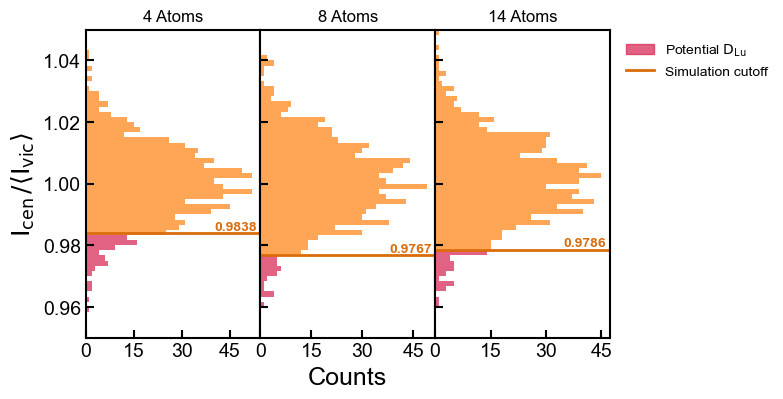

In [8]:
hist_min = 0.95
hist_max = 1.05
n_bins = 60
dlu_cutoffs = {
    name: values.min() for name, values in pristine_intensities.items()
}
dlu_maps = {
    name: (values < dlu_cutoffs[name])
    & experimental_lu_mask
    & np.isfinite(values)
    for name, values in experimental_relative.items()
}
dlu_map_combined = np.logical_and.reduce(list(dlu_maps.values()))
np.save("DLu_indices.npy", np.argwhere(dlu_map_combined))
valid_lu_sites_all_metrics = experimental_lu_mask & np.logical_and.reduce([
    np.isfinite(values) for values in experimental_relative.values()
])

fig, axes = plt.subplots(1, len(configs), figsize=(8, 4), sharey=True)

for ax, name in zip(axes, configs):
    cutoff = dlu_cutoffs[name]
    values = experimental_relative[name]
    values = values[experimental_lu_mask & np.isfinite(values)]
    counts, edges = np.histogram(
        values, bins=n_bins, range=(hist_min, hist_max)
    )
    centers = (edges[:-1] + edges[1:]) / 2
    colors = np.where(centers < cutoff, "#D6204E", "#ff7f0e")
    ax.barh(centers, counts, height=np.diff(edges), color=colors, alpha=0.7)
    # ax.axhline(values.mean(), color="#da6c0c", linestyle="--")
    ax.axhline(cutoff, color="#da6c0c", linewidth=2)
    transform = ax.get_yaxis_transform()
    ax.text(0.98, cutoff, f"{cutoff:.4f}", transform=transform, ha="right", va="bottom", color="#da6c0c", fontweight="bold")
    # ax.text(0.98, values.mean(), f"{values.mean():.4f}", transform=transform, ha="right", va="bottom", color="#da6c0c")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True, prune="upper"))
    ax.tick_params(direction="in", length=6)
    ax.set_ylim(hist_min, hist_max)

legend = [
    LegendPatch(color="#D6204E", alpha=0.7, label=r"Potential $\mathrm{D}_{\mathrm{Lu}}$"),
    # LegendPatch(color="#ff7f0e", alpha=0.7, label=r"Potential non-defects"),
    Line2D([0], [0], color="#da6c0c", linewidth=2, label="Simulation cutoff"),
    # Line2D([0], [0], color="#da6c0c", linestyle="--", label="Mean"),
]
axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
axes[-1].legend(handles=legend, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.78)
plt.show()

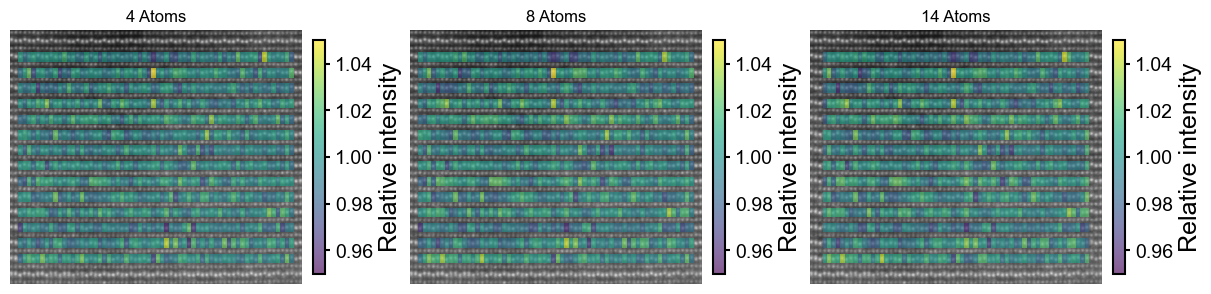

In [9]:
fig, axes = plt.subplots(
    1, len(configs), figsize=(12, 5), constrained_layout=True
)

for ax, (name, values) in zip(axes, experimental_relative.items()):
    plotter = roi_tools.PatchGridPlotter(
        experimental_signal, experimental_grid, ax=ax
    )
    artist = plotter.add_patch_faces(
        atom_type="Lu", values=values, cmap="viridis",
        vmin=hist_min, vmax=hist_max, alpha=0.65,
    )
    plotter.add_colorbar(
        artist, fraction=0.04, label="Relative intensity"
    )
    ax.set_title(name)
    ax.set_axis_off()

plt.show()

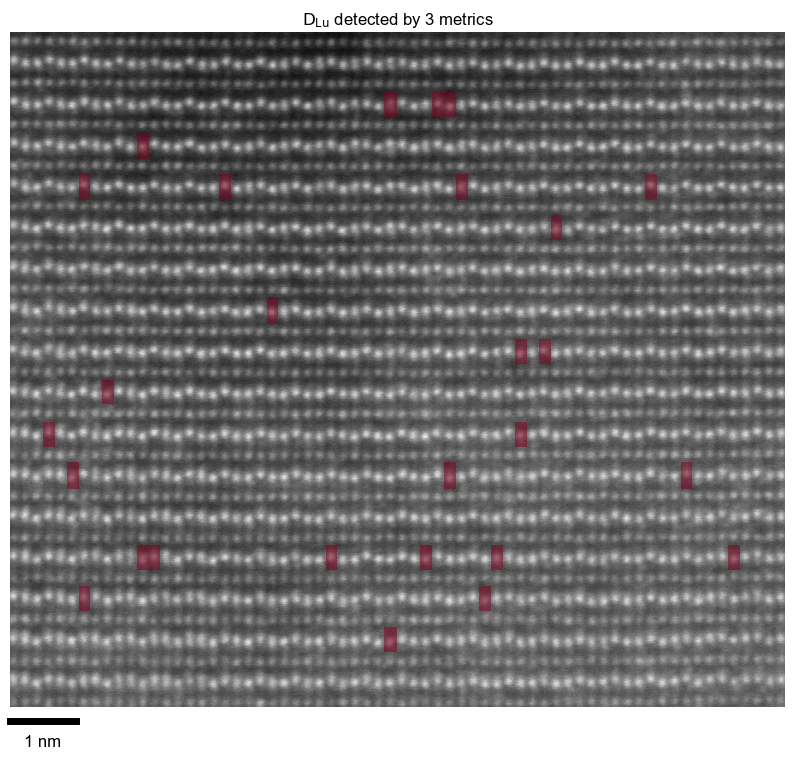

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '$\\mathrm{D}_{\\mathrm{Lu}}$ detected by 3 metrics'}>)

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
experimental_plotter = roi_tools.PatchGridPlotter(
    experimental_signal, experimental_grid, ax=ax
)
experimental_plotter.add_boolean_faces(
    dlu_map_combined, color="#820021", alpha=0.5, linewidth=1
)
ax.set_title(r"$\mathrm{D}_{\mathrm{Lu}}$ detected by 3 metrics")
experimental_plotter.show(
    axis_on=False, scale_nm=1, scale_linewidth=5, scale_fontsize=12
)

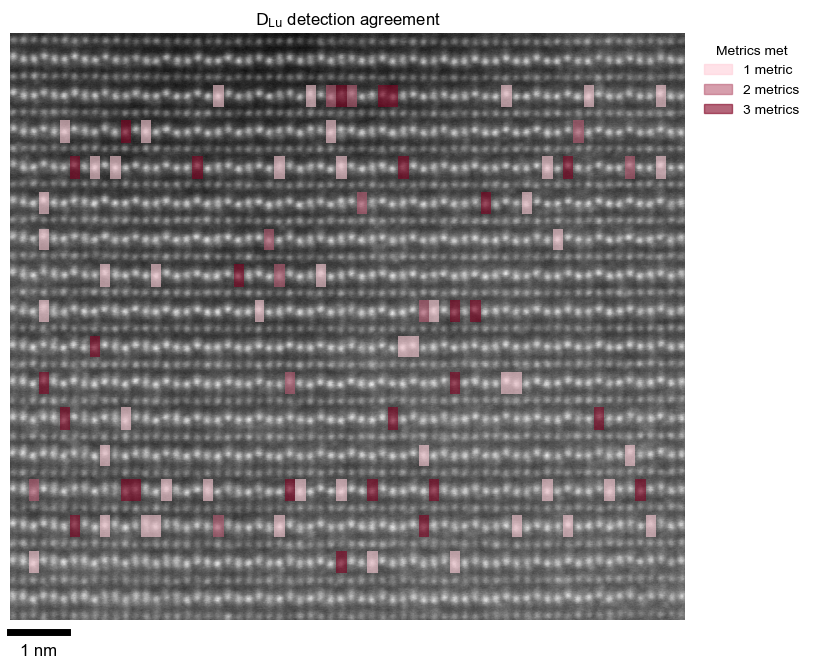

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '$\\mathrm{D}_{\\mathrm{Lu}}$ detection agreement'}>)

In [11]:
dlu_detection_count = np.sum(
    np.stack(list(dlu_maps.values())), axis=0
)
tier_colors = {
    1: "#FFCFD9",
    2: "#BB5D75",
    3: "#820021",
}

fig, ax = plt.subplots(figsize=(10, 10))
experimental_plotter = roi_tools.PatchGridPlotter(
    experimental_signal, experimental_grid, ax=ax
)
for count, color in tier_colors.items():
    experimental_plotter.add_boolean_faces(
        dlu_detection_count == count,
        color=color, alpha=0.6, linewidth=1,
    )

ax.legend(
    handles=[
        LegendPatch(
            color=color, alpha=0.6, label=f"{count} metric"
            if count == 1 else f"{count} metrics"
        )
        for count, color in tier_colors.items()
    ],
    frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left",
    title="Metrics met",
)
ax.set_title(r"$\mathrm{D}_{\mathrm{Lu}}$ detection agreement")
fig.subplots_adjust(right=0.8)
experimental_plotter.show(
    axis_on=False, scale_nm=1, scale_linewidth=5, scale_fontsize=12
)

In [12]:
dlu_detection_summary = pd.DataFrame({
    "D_Lu detected by all 3 metrics": [
        np.count_nonzero(dlu_map_combined)
    ],
    "Valid Lu sites for all 3 metrics": [
        np.count_nonzero(valid_lu_sites_all_metrics)
    ],
})
dlu_detection_summary

,D_Lu detected by all 3 metrics,Valid Lu sites for all 3 metrics
0,27,840
